In [1]:
import sys
sys.path.append('/app')
# unit_test/test_single_receptor.py
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import os
from itertools import cycle

from src import (generate_receptor_indices, 
                plot_family_summary,                
                plot_latent_radar_chart,
                evaluate_model,
                plot_summary,
                plot_latent_umap)
from run import run,initialize


In [2]:
CONF = {
        "n_units": 2,
        "n_families": 1,
        "latent_dim": 5,
        "k_sub": 5,
        "batch_size": 1024,
        "epochs": 600,
        "lr": 0.05,
        "cov_weight":10.,
        "n_bins":2,
        "bin_temp":0.05,
        "receptor_indices":torch.tensor([[0,0,0,0,0],[1,1,1,1,1]],dtype=torch.long)
    }

In [3]:
env,physics,loss_fn,optimize = initialize(CONF)

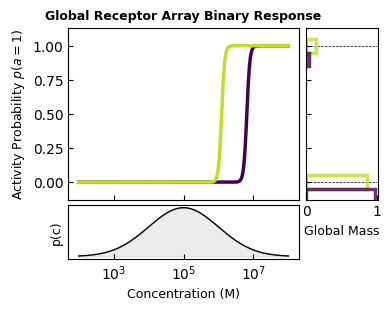

In [4]:
fig,ax = plot_summary(env,physics,CONF["receptor_indices"])

In [5]:
stats = run(CONF,env,physics,loss_fn,optimize)

Training for 600 epochs...
Total Correlation: 0.0386
Total Correlation: 0.0988
Total Correlation: 0.1960
Total Correlation: 0.1527
Total Correlation: 0.1287
Total Correlation: 0.1089
Total Correlation: 0.0968
Total Correlation: 0.1029
Total Correlation: 0.0787
Total Correlation: 0.0975
Total Correlation: 0.0511
Total Correlation: 0.0631
Total Correlation: 0.0493
Total Correlation: 0.0553
Total Correlation: 0.0478
Total Correlation: 0.0553
Total Correlation: 0.0329
Total Correlation: 0.0400
Total Correlation: 0.0413
Total Correlation: 0.0277
Total Correlation: 0.0226
Total Correlation: 0.0506
Total Correlation: 0.0292
Total Correlation: 0.0507
Total Correlation: 0.0163
Total Correlation: 0.0135
Total Correlation: 0.0147
Total Correlation: 0.0102
Total Correlation: 0.0238
Total Correlation: 0.0186
Total Correlation: 0.0098
Total Correlation: 0.0184
Total Correlation: 0.0059
Total Correlation: 0.0072
Total Correlation: 0.0084
Total Correlation: 0.0039
Total Correlation: 0.0099
Total Corre

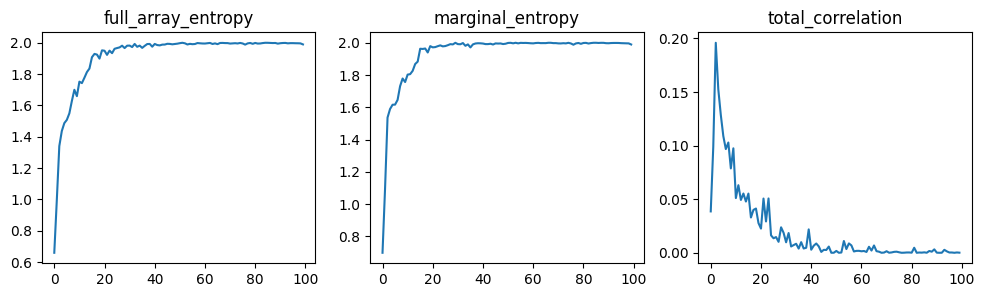

In [6]:
fig,ax = plt.subplots(ncols=3,figsize=(3*4,3))
for i,key in enumerate(stats.keys()):
    ax[i].plot(stats[key])
    ax[i].set_title(key)

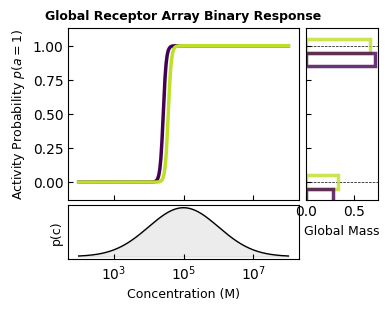

In [15]:
fig,ax = plot_summary(env,physics,CONF["receptor_indices"])

In [9]:
energies, concs, _ = env.sample_batch(CONF['batch_size'])
activity = physics(energies, concs, CONF["receptor_indices"])

In [10]:
loss_fn._compute_soft_histogram_entropy(activity)

tensor([0.9986, 0.9998], device='cuda:0', grad_fn=<NegBackward0>)

In [12]:
import math

In [13]:
bin_temp = 0.05
n_bins = 2

B, R = activity.shape
        
# 1. Expand dimensions to compute distances to all bin centers
# activity: (Batch, R, 1) | bin_centers: (1, 1, n_bins)
act_expanded = activity.unsqueeze(-1)

bin_centers = torch.linspace(0.0, 1.0, n_bins)
#centers = self.bin_centers.to(activity.device)
centers_expanded = bin_centers.to(activity.device).unsqueeze(0).unsqueeze(0)

# 2. Compute Squared Distance
# Shape: (Batch, R, n_bins)
dist_sq = (act_expanded - centers_expanded) ** 2

# 3. Soft Assignment using Softmax over the bins dimension
# A smaller bin_temp makes the assignment act more like a hard step-function
soft_assign = torch.softmax(-dist_sq / bin_temp, dim=-1)

# 4. Marginal Probability of falling into each bin
# Average over the batch. Shape: (R, n_bins)
p_marginal = soft_assign.mean(dim=0)

# 5. Clamp to prevent log2(0) crashes
p_marginal = torch.clamp(p_marginal, min=1e-12)

# Calculate log base K using the change-of-base formula: ln(p) / ln(K)
log_k_p = torch.log(p_marginal) / math.log(n_bins)

# Exact Normalized Shannon Entropy
entropy = -torch.sum(p_marginal * log_k_p, dim=-1)

In [14]:
p_marginal

tensor([[0.4784, 0.5216],
        [0.5092, 0.4908]], device='cuda:0', grad_fn=<ClampBackward1>)